# 🎫 Support Ticket Classification System

An end-to-end NLP pipeline that automatically:
1. **Cleans & tokenizes** raw ticket text
2. **Classifies** tickets into support categories
3. **Assigns a priority level** (high / medium / low) using a hybrid ML + rule-based approach
4. **Evaluates** model performance with standard metrics

**Tools:** Python, NLTK, Scikit-learn

---


## 1. Setup & Imports

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, accuracy_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)

# ---------------------------------------------------------------
# NLTK is used for stopwords + lemmatization. If NLTK / its data
# packages aren't available (e.g. no internet access), we fall
# back to a small built-in stopword list and a lightweight suffix
# stripper so the notebook still runs end-to-end.
# ---------------------------------------------------------------
try:
    import nltk
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)
    from nltk.corpus import stopwords as nltk_stopwords
    from nltk.stem import WordNetLemmatizer

    STOPWORDS = set(nltk_stopwords.words("english"))
    _lemmatizer = WordNetLemmatizer()

    def lemmatize(token):
        return _lemmatizer.lemmatize(token)

    NLTK_READY = True
except Exception as e:
    print("NLTK data unavailable, using fallback preprocessing:", e)
    STOPWORDS = set('''a an the is are was were be been being to of in on for and or but if
    then so than that this these those i you he she it we they me him her us them my your
    his its our their as at by with from up down out about into over under again further
    do does did doing have has had having not no nor can will just should now'''.split())

    def lemmatize(token):
        for suf in ("ing", "ies", "ed", "es", "s"):
            if token.endswith(suf) and len(token) > len(suf) + 2:
                return token[: -len(suf)]
        return token

    NLTK_READY = False

print("NLTK preprocessing active:", NLTK_READY)


NLTK preprocessing active: True


## 2. Load the Dataset

This notebook ships with `sample_tickets.csv` — a small synthetic dataset of support
tickets labeled with `category` and `priority`, so you can run the whole pipeline
immediately.

**To use your own data:** replace the path below with your CSV. It needs at minimum
a `text` column; `category` and `priority` columns are needed for training (if you
only have `text`, skip to Section 9 and use the pipeline in *inference-only* mode
with the pre-trained models).

In [2]:
DATA_PATH = "sample_tickets.csv"  # <-- point this at your own ticket export if you have one

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} tickets")
df.head()


Loaded 102 tickets


,ticket_id,text,category,priority
0,1030,Just wondering if you plan to support dark mode soon.,Technical Issue,low
1,1067,Minor bug: the tooltip text is slightly cut off on smaller screens.,Bug Report,low
2,1062,The export button produces a corrupted file sometimes.,Bug Report,medium
3,1047,Can you help me merge two accounts under one login?,Account Access,medium
4,1042,"My account shows the wrong subscription plan, can someone check?",Account Access,medium


## 3. Exploratory Data Analysis

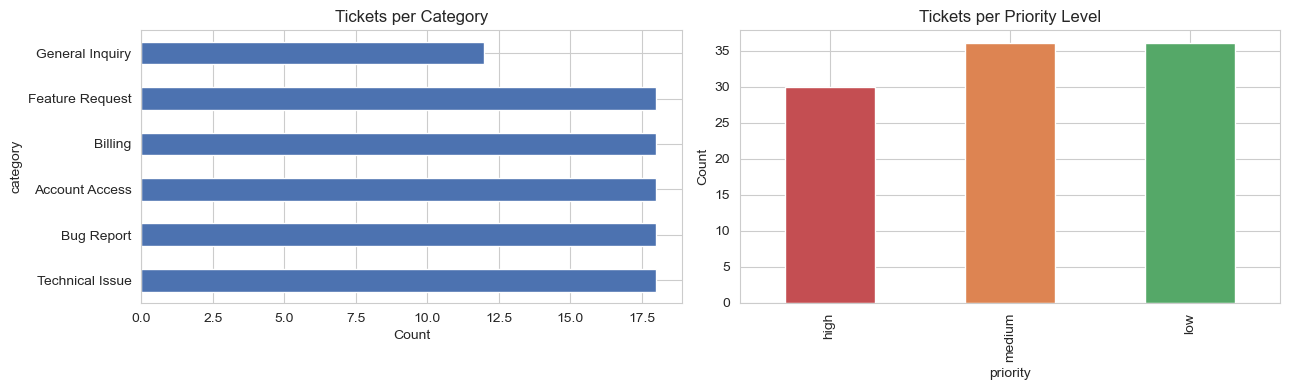

category
Technical Issue    18
Bug Report         18
Account Access     18
Billing            18
Feature Request    18
General Inquiry    12
Name: count, dtype: int64

priority
low       36
medium    36
high      30
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["category"].value_counts().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Tickets per Category")
axes[0].set_xlabel("Count")

df["priority"].value_counts().reindex(["high", "medium", "low"]).plot(
    kind="bar", ax=axes[1], color=["#C44E52", "#DD8452", "#55A868"])
axes[1].set_title("Tickets per Priority Level")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(df["category"].value_counts())
print()
print(df["priority"].value_counts())


## 4. Text Preprocessing

Standard NLP cleaning pipeline:
1. Lowercase
2. Strip URLs and non-alphanumeric characters
3. Tokenize on whitespace
4. Remove stopwords
5. Lemmatize each token


In [4]:
def clean_text(text: str) -> str:
    """Lowercase, strip noise, tokenize, remove stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [lemmatize(tok) for tok in text.split() if tok not in STOPWORDS and len(tok) > 1]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()


,text,clean_text
0,Just wondering if you plan to support dark mode soon.,wondering plan support dark mode soon
1,Minor bug: the tooltip text is slightly cut off on smaller screens.,minor bug tooltip text slightly cut smaller screen
2,The export button produces a corrupted file sometimes.,export button produce corrupted file sometimes
3,Can you help me merge two accounts under one login?,help merge two account one login
4,"My account shows the wrong subscription plan, can someone check?",account show wrong subscription plan someone check


## 5. Feature Engineering

Two feature sets are built:
- **TF-IDF vectors** (unigrams + bigrams) capture the topical content of the ticket
- **Urgency score**: a rule-based count of urgency-signaling keywords (e.g. *urgent*,
  *immediately*, *down*, *locked*, *deadline*). This engineered feature is later combined
  with the ML model for priority tagging, and also acts as a safety-net override for
  unmistakably urgent language.


In [5]:
URGENCY_WORDS = {
    "urgent", "immediately", "asap", "now", "critical", "right", "cannot", "cant",
    "broken", "down", "locked", "lost", "deadline", "escalate", "emergency",
}

def urgency_score(raw_text: str) -> int:
    t = str(raw_text).lower()
    return sum(1 for w in URGENCY_WORDS if w in t)

df["urgency_score"] = df["text"].apply(urgency_score)
df[["text", "urgency_score"]].sort_values("urgency_score", ascending=False).head()


,text,urgency_score
47,"Login is completely broken for our whole team right now, please help urgently.",4
73,"I've been locked out of my account and need access restored immediately, it's urgent.",3
61,"I've been locked out of my account and need access restored immediately, it's urgent.",3
5,"I've been locked out of my account and need access restored immediately, it's urgent.",3
54,URGENT: my card was charged $49.00 in error and I need a refund right now.,3


## 6. Category Classification Model

Three classic text-classification models are trained and compared:
- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes

The best performer on held-out accuracy is kept as the production category model.


In [6]:
train_df, test_df = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df["category"]
)

cat_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_train_cat = cat_vectorizer.fit_transform(train_df["clean_text"])
X_test_cat = cat_vectorizer.transform(test_df["clean_text"])

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Multinomial Naive Bayes": MultinomialNB(),
}

results = {}
for name, model in candidate_models.items():
    model.fit(X_train_cat, train_df["category"])
    preds = model.predict(X_test_cat)
    acc = accuracy_score(test_df["category"], preds)
    f1 = f1_score(test_df["category"], preds, average="weighted")
    results[name] = {"model": model, "accuracy": acc, "f1": f1}
    print(f"{name:28s}  accuracy={acc:.3f}  weighted-F1={f1:.3f}")

best_cat_name = max(results, key=lambda k: results[k]["f1"])
best_cat_model = results[best_cat_name]["model"]
print(f"\nSelected category model: {best_cat_name}")


Logistic Regression           accuracy=0.962  weighted-F1=0.962
Linear SVM                    accuracy=0.846  weighted-F1=0.837
Multinomial Naive Bayes       accuracy=0.923  weighted-F1=0.917

Selected category model: Logistic Regression


## 7. Category Model Evaluation

                 precision    recall  f1-score   support

 Account Access       1.00      1.00      1.00         5
        Billing       0.80      1.00      0.89         4
     Bug Report       1.00      0.80      0.89         5
Feature Request       1.00      1.00      1.00         5
General Inquiry       1.00      1.00      1.00         3
Technical Issue       1.00      1.00      1.00         4

       accuracy                           0.96        26
      macro avg       0.97      0.97      0.96        26
   weighted avg       0.97      0.96      0.96        26



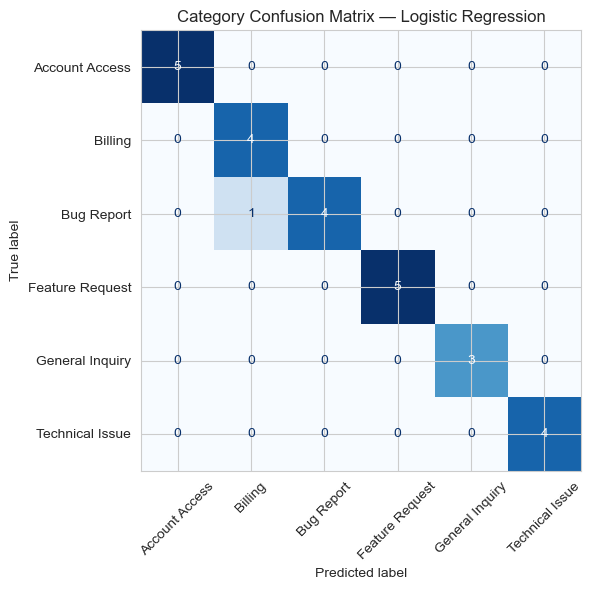

In [7]:
cat_preds = best_cat_model.predict(X_test_cat)
print(classification_report(test_df["category"], cat_preds))

labels = sorted(df["category"].unique())
cm = confusion_matrix(test_df["category"], cat_preds, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title(f"Category Confusion Matrix — {best_cat_name}")
plt.tight_layout()
plt.show()


## 8. Priority Tagging (Hybrid Model)

Priority is trickier than topic classification: two tickets in the same category can
have very different urgency. The approach combines:

1. **ML classifier** trained on TF-IDF text features *plus* the engineered
   `urgency_score` feature
2. **Rule-based override**: if a ticket contains 3+ strong urgency keywords, it is
   force-tagged `high` regardless of the model's prediction — a safety net so that
   unmistakably urgent language is never under-prioritized.


In [8]:
train_df2, test_df2 = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df["priority"]
)

pri_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_text = pri_vectorizer.fit_transform(train_df2["clean_text"])
X_test_text = pri_vectorizer.transform(test_df2["clean_text"])

X_train_pri = hstack([X_train_text, train_df2[["urgency_score"]].values])
X_test_pri = hstack([X_test_text, test_df2[["urgency_score"]].values])

priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train_pri, train_df2["priority"])

raw_preds = priority_model.predict(X_test_pri)

# apply the rule-based safety-net override
final_preds = []
for raw_text, pred in zip(test_df2["text"], raw_preds):
    final_preds.append("high" if urgency_score(raw_text) >= 3 else pred)

print("ML-only accuracy:      ", accuracy_score(test_df2["priority"], raw_preds))
print("Hybrid (ML+rules) acc: ", accuracy_score(test_df2["priority"], final_preds))


ML-only accuracy:       0.8846153846153846
Hybrid (ML+rules) acc:  0.8846153846153846


## 9. Priority Model Evaluation

              precision    recall  f1-score   support

        high       1.00      1.00      1.00         8
         low       0.80      0.89      0.84         9
      medium       0.88      0.78      0.82         9

    accuracy                           0.88        26
   macro avg       0.89      0.89      0.89        26
weighted avg       0.89      0.88      0.88        26



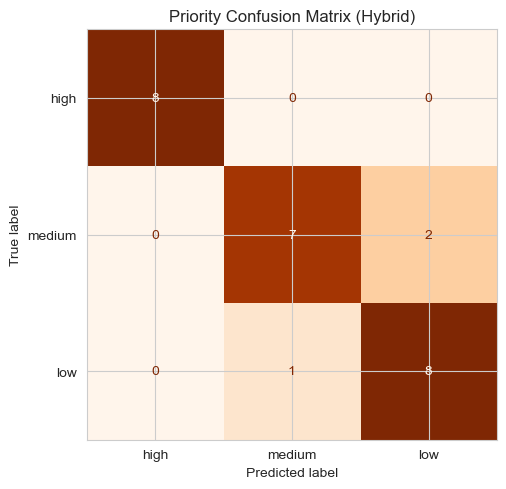

In [9]:
print(classification_report(test_df2["priority"], final_preds))

pri_labels = ["high", "medium", "low"]
cm2 = confusion_matrix(test_df2["priority"], final_preds, labels=pri_labels)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm2, display_labels=pri_labels).plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Priority Confusion Matrix (Hybrid)")
plt.tight_layout()
plt.show()


## 10. End-to-End Pipeline

A single function that takes a raw ticket string and returns the predicted category,
priority, and the model's confidence — ready to plug into a support-desk workflow.


In [10]:
def classify_ticket(text: str) -> dict:
    """Classify a raw support ticket into a category + priority."""
    cleaned = clean_text(text)
    u_score = urgency_score(text)

    # --- category ---
    cat_vec = cat_vectorizer.transform([cleaned])
    category = best_cat_model.predict(cat_vec)[0]
    if hasattr(best_cat_model, "predict_proba"):
        cat_confidence = float(best_cat_model.predict_proba(cat_vec).max())
    else:
        cat_confidence = None  # LinearSVC has no predict_proba

    # --- priority ---
    pri_vec = pri_vectorizer.transform([cleaned])
    pri_full = hstack([pri_vec, np.array([[u_score]])])
    priority = priority_model.predict(pri_full)[0]
    pri_confidence = float(priority_model.predict_proba(pri_full).max())

    if u_score >= 3:
        priority = "high"

    return {
        "category": category,
        "category_confidence": cat_confidence,
        "priority": priority,
        "priority_confidence": pri_confidence,
        "urgency_score": u_score,
    }


demo_tickets = [
    "Our production server is down and no customers can check out, please help immediately!",
    "Just wondering how to change my display name.",
    "I was charged twice for my subscription this month, can someone check the invoice?",
    "Found a bug that deletes user data permanently, this needs immediate attention.",
]

for t in demo_tickets:
    result = classify_ticket(t)
    print(f"TICKET: {t}")
    print(f"  -> category={result['category']}  priority={result['priority']}"
          f"  (urgency_score={result['urgency_score']})")
    print()


TICKET: Our production server is down and no customers can check out, please help immediately!
  -> category=Technical Issue  priority=high  (urgency_score=2)

TICKET: Just wondering how to change my display name.
  -> category=Account Access  priority=low  (urgency_score=0)

TICKET: I was charged twice for my subscription this month, can someone check the invoice?
  -> category=Billing  priority=medium  (urgency_score=0)

TICKET: Found a bug that deletes user data permanently, this needs immediate attention.
  -> category=Bug Report  priority=high  (urgency_score=0)



## 11. Save Model Artifacts

Persist the trained vectorizers and models so they can be loaded in a production service without retraining.

In [11]:
joblib.dump(cat_vectorizer, "category_vectorizer.joblib")
joblib.dump(best_cat_model, "category_model.joblib")
joblib.dump(pri_vectorizer, "priority_vectorizer.joblib")
joblib.dump(priority_model, "priority_model.joblib")

print("Saved: category_vectorizer.joblib, category_model.joblib, priority_vectorizer.joblib, priority_model.joblib")


Saved: category_vectorizer.joblib, category_model.joblib, priority_vectorizer.joblib, priority_model.joblib


## 12. Summary & Next Steps

**What this notebook delivers:**
- ✅ Text cleaning & tokenization (NLTK-based, with an offline fallback)
- ✅ Multi-class ticket **category** classification (compared 3 models, auto-selected the best)
- ✅ Hybrid ML + rule-based **priority** tagging (high / medium / low)
- ✅ Full evaluation: accuracy, F1, per-class precision/recall, confusion matrices
- ✅ A single `classify_ticket()` function ready for integration
- ✅ Saved model artifacts for deployment

**To adapt this to your real ticket data:**
1. Replace `sample_tickets.csv` with your own export (needs `text`, and ideally
   historical `category` / `priority` labels).
2. Re-run Sections 6–9 to retrain on your data.
3. If you don't have priority labels yet, start with the rule-based `urgency_score`
   alone, then bootstrap ML priority tagging once you've accumulated agent-assigned
   labels.

**Possible extensions:**
- Add SLA-based priority (e.g. enterprise customers auto-escalate)
- Incorporate ticket metadata (customer tier, product area, past ticket count)
- Swap TF-IDF for embeddings (e.g. sentence-transformers) for better semantic matching
- Add a lightweight Flask/FastAPI wrapper around `classify_ticket()` for real-time use
